In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


In [ ]:
# data preprocessing

data = pd.read_csv('../data/churn.csv')
# data.info()

data = pd.get_dummies(data, columns=['Churn', 'gender'])  # one-hot encoding
# data.info()

data.drop(columns=['gender_Male', 'Churn_No'], inplace=True)
data.rename(columns={'Churn_Yes': 'flag'}, inplace=True)
# data.info()

print(data.flag.value_counts())
data.info()

flag
False    5174
True     1869
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Partner_att        7043 non-null   int64  
 1   Dependents_att     7043 non-null   int64  
 2   landline           7043 non-null   int64  
 3   internet_att       7043 non-null   int64  
 4   internet_other     7043 non-null   int64  
 5   StreamingTV        7043 non-null   int64  
 6   StreamingMovies    7043 non-null   int64  
 7   Contract_Month     7043 non-null   int64  
 8   Contract_1YR       7043 non-null   int64  
 9   PaymentBank        7043 non-null   int64  
 10  PaymentCreditcard  7043 non-null   int64  
 11  PaymentElectronic  7043 non-null   int64  
 12  MonthlyCharges     7043 non-null   float64
 13  TotalCharges       7043 non-null   float64
 14  flag               7043 non-null   bool   
 15  gender_Female      7043 

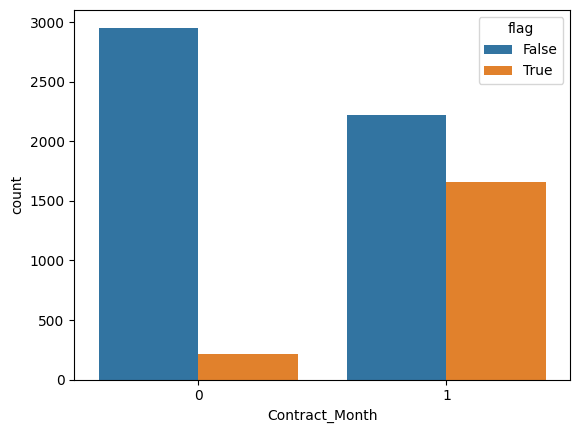

In [ ]:
# data visualization

sns.countplot(data, x='Contract_Month', hue='flag')  # 0：不是会员；1：是会员
plt.show()

In [23]:
# model train and eval

x = data[['Contract_Month', 'PaymentElectronic', 'internet_other']]
y = data['flag']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23)

estimator = LogisticRegression()
estimator.fit(x_train, y_train)

y_pred = estimator.predict(x_test)
print(f'y pred: {y_pred}')
print(f'classification report: \n {classification_report(y_test, y_pred)}')

# macro avg, weight avg：将precision, recall, f1 score分别对每个类别求平均，macro avg是简单平均，weight avg是加权平均（权重是每个类别的样本数占总样本数的比例）

y pred: [False False  True  True False  True False False False False False False
 False False False  True  True False  True False False  True False False
 False  True False False False False False False  True False False False
 False False False False False False False  True False False  True False
 False False  True False False  True False  True False False  True False
 False False False False False False False False False False False False
 False False False  True  True False False  True False False False False
 False  True  True False False  True False False False False False False
  True False False False False False False False False False  True False
 False False False  True False False False False False  True False False
  True False  True False False False False False False False False False
 False False  True  True False False False False  True False False False
  True False False False False False  True False False False False False
 False False False False False  True False 